In [ ]:
import pandas as pd
import numpy as np

# Core dataset config
file_path = 'equipment_failure_data_1.csv'
target = 'EQUIPMENT_FAILURE'
region_col = 'REGION_CLUSTER'   # LOGO grouping (assignment rule)
seq_id_col = 'ID'              # sequential grouping (or WELL_GROUP if you prefer)
date_col = 'DATE'

categorical_features = ['MAINTENANCE_VENDOR', 'MANUFACTURER', 'WELL_GROUP']
numerical_features = ['S15', 'S17', 'S13', 'S5', 'S16', 'S19', 'S18', 'S8', 'AGE_OF_EQUIPMENT']

# 1) Load raw data (NO scaling/encoding here to avoid leakage across LOGO folds)
df_raw = pd.read_csv(file_path)

# 2) Parse + sort sequentially BEFORE any split/feature engineering
df_raw[date_col] = pd.to_datetime(df_raw[date_col], errors='coerce')
df_raw = df_raw.sort_values([seq_id_col, date_col]).reset_index(drop=True)

print('raw shape:', df_raw.shape)
print('regions:', df_raw[region_col].nunique())
print('date range:', df_raw[date_col].min(), '->', df_raw[date_col].max())
print('missing DATE:', int(df_raw[date_col].isna().sum()))

C:\Users\dirkg\AppData\Local\Temp\ipykernel_33316\3870607778.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['DATE'] = pd.to_datetime(df_eda['DATE'])


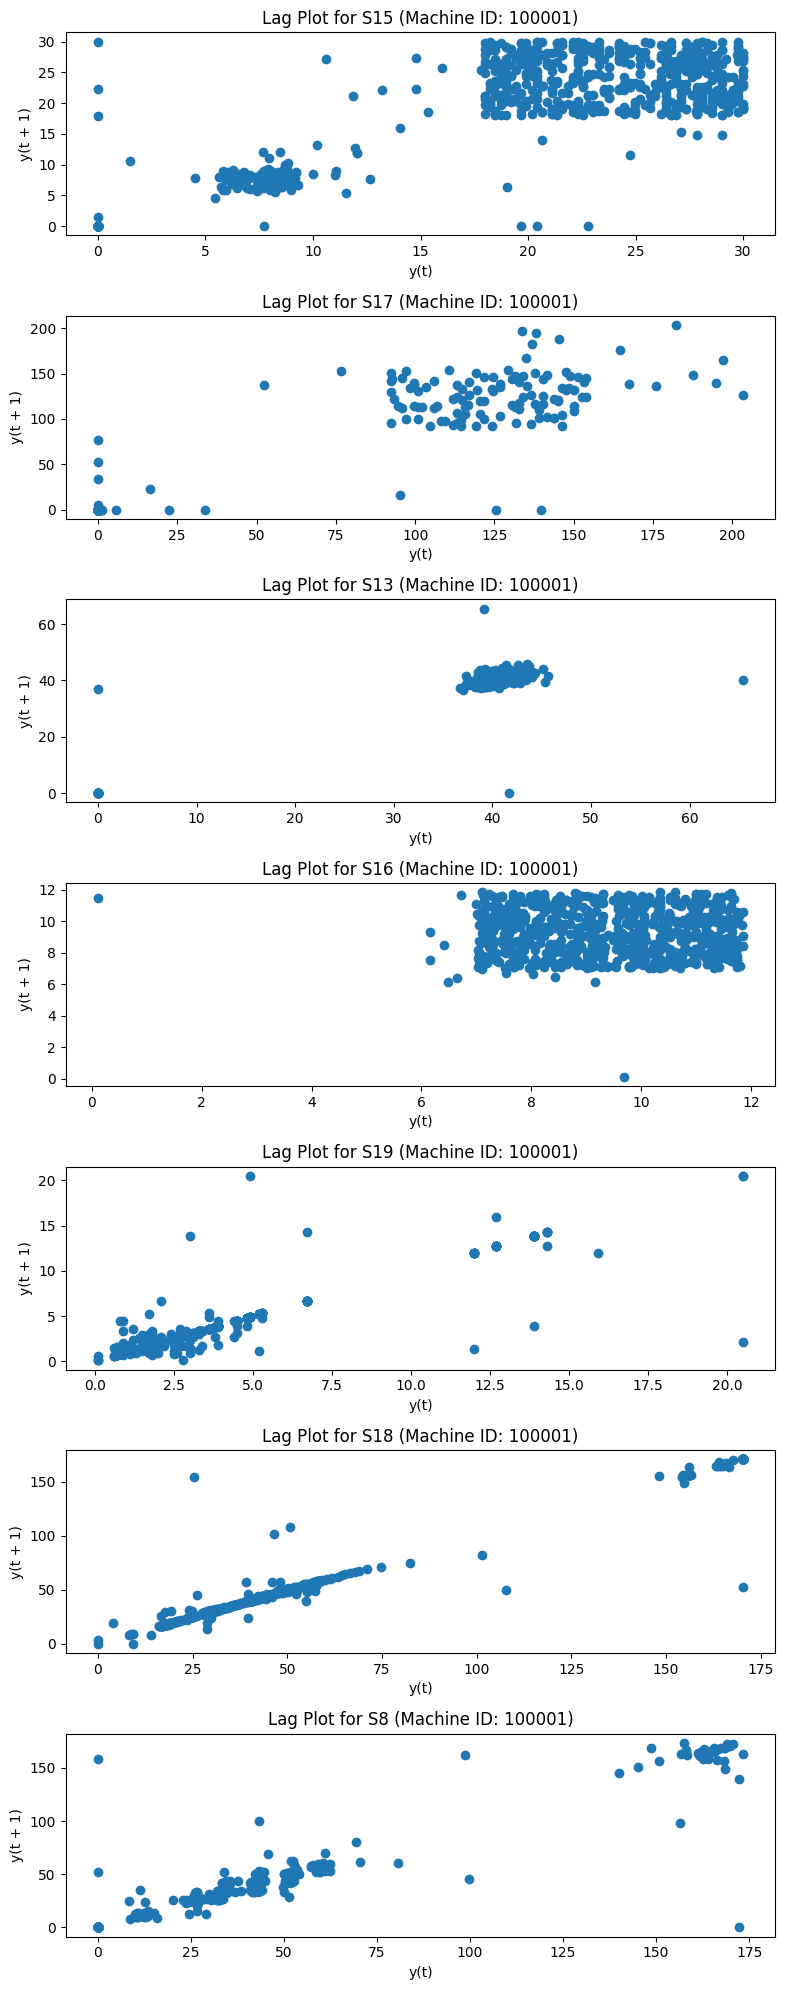

In [3]:
%pip uninstall -y sklearn
%pip install -q -U scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

# 1. Load the data
file_path = "equipment_failure_data_1.csv"
df_eda = pd.read_csv(file_path)

# 2. Convert DATE and sort
df_eda['DATE'] = pd.to_datetime(df_eda['DATE'])

# It's safer to sort by the specific machine/well, then by date
df_eda = df_eda.sort_values(by=['ID', 'DATE'])
df_eda.set_index('DATE', inplace=True)

# 3. Filter for just ONE machine to get a true sequential lag plot
# Let's just take the first ID in the dataset as an example
sample_id = df_eda['ID'].iloc[0]
df_sample = df_eda[df_eda['ID'] == sample_id]

# 4. Plot
sensor_cols = ['S15', 'S17', 'S13', 'S16', 'S19', 'S18', 'S8']
fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(8, 20))

for i, sensor in enumerate(sensor_cols):
    lag_plot(df_sample[sensor], ax=axes[i])
    axes[i].set_title(f'Lag Plot for {sensor} (Machine ID: {sample_id})')

plt.tight_layout()
plt.show()

Reminder: shuffling is allowed **only after** the split, and only for the **training** portion (never shuffle the full dataset before LOGO).

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

SENSOR_COLS = ['S15', 'S17', 'S13', 'S5', 'S16', 'S19', 'S18', 'S8']

def _seq_group_cols(df: pd.DataFrame, id_col: str, region_col: str):
    # If an ID appears in multiple regions, include region in the sequential grouping to avoid cross-region leakage.
    max_regions_per_id = df.groupby(id_col)[region_col].nunique().max()
    return [id_col] if max_regions_per_id <= 1 else [id_col, region_col]

def add_lag_features(df: pd.DataFrame, group_cols, date_col: str, sensor_cols, lags=(1, 2, 3)):
    df = df.sort_values(group_cols + [date_col]).copy()
    for lag in lags:
        for col in sensor_cols:
            df[f'{col}_lag{lag}'] = df.groupby(group_cols)[col].shift(lag)
    return df

def split_logo_by_region(df: pd.DataFrame, region_col: str):
    regions = sorted(df[region_col].dropna().unique())
    for held_out in regions:
        train_df = df[df[region_col] != held_out].copy()
        test_df = df[df[region_col] == held_out].copy()
        yield held_out, train_df, test_df

def preprocess_fold(train_df: pd.DataFrame, test_df: pd.DataFrame, *,
                    categorical_cols, numerical_cols, drop_cols, target_col, shuffle_train=False, seed=0):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Optional training shuffle (allowed only after split)
    if shuffle_train:
        train_df = train_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # Scale numeric using TRAIN stats only (leakage-safe)
    mu = train_df[numerical_cols].mean()
    sigma = train_df[numerical_cols].std().replace(0, 1)
    train_df[numerical_cols] = (train_df[numerical_cols] - mu) / sigma
    test_df[numerical_cols] = (test_df[numerical_cols] - mu) / sigma

    # One-hot encode using TRAIN columns only (align test)
    train_enc = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True, dtype=int)
    test_enc = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True, dtype=int)

    y_train = train_enc[target_col].astype(int)
    y_test = test_enc[target_col].astype(int)

    X_train = train_enc.drop(columns=drop_cols, errors='ignore')
    X_test = test_enc.drop(columns=drop_cols, errors='ignore')

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    return X_train, y_train, X_test, y_test


# --- Build leakage-safe features, then evaluate LOGO baselines ---
seq_groups = _seq_group_cols(df_raw, seq_id_col, region_col)
df_fe = add_lag_features(df_raw, seq_groups, date_col, SENSOR_COLS, lags=(1, 2, 3))

lag_cols = [c for c in df_fe.columns if any(c.endswith(f'_lag{l}') for l in (1, 2, 3))]
numeric_cols = numerical_features + lag_cols

# Drop initial rows per sequence that don't have lag history
df_fe = df_fe.dropna(subset=lag_cols + numerical_features + [target, region_col])

drop_cols = [target, region_col, seq_id_col, date_col]

results = []
rf_importance_rows = []
for held_out, train_df, test_df in split_logo_by_region(df_fe, region_col):
    X_train, y_train, X_test, y_test = preprocess_fold(
        train_df,
        test_df,
        categorical_cols=categorical_features,
        numerical_cols=numeric_cols,
        drop_cols=drop_cols,
        target_col=target,
        shuffle_train=False,
        seed=0,
    )

    models = {
        'dt': DecisionTreeClassifier(random_state=0, class_weight='balanced'),
        'rf': RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1, class_weight='balanced'),
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        results.append({
            'held_out_region': held_out,
            'model': name,
            'precision': float(precision_score(y_test, pred, zero_division=0)),
            'recall': float(recall_score(y_test, pred, zero_division=0)),
            'f1': float(f1_score(y_test, pred, zero_division=0)),
            'n_train': int(len(y_train)),
            'n_test': int(len(y_test)),
        })

        if name == 'rf':
            rf_importance_rows.append(
                pd.Series(model.feature_importances_, index=X_train.columns, name=str(held_out))
            )

df_foreign_results = pd.DataFrame(results).sort_values(['model', 'f1'], ascending=[True, False]).reset_index(drop=True)

df_rf_importance = (
    pd.concat(rf_importance_rows, axis=1)
    .T
    .rename_axis('held_out_region')
    .reset_index()
)

df_foreign_results

## Next steps: required experiments

What you have now:
- LOGO **Foreign** evaluation: train on all other `REGION_CLUSTER` values, test on the held-out region (Decision Tree + Random Forest).

What we add next:
1) **Local benchmark**: train/test inside the *same* region with a **time-based** split (no random split).
2) **Local → Foreign drop** table for Recall and F1.
3) Optional: a single explicit **A→E** style run (choose train regions and one test region).
4) Optional: **transfer learning** with a simple MLP (pretrain on other regions, fine-tune on limited target data).


In [ ]:
# Summaries + feature stability (RF importances per held-out region)

display(df_foreign_results.groupby('model')[['precision', 'recall', 'f1']].agg(['mean', 'std', 'min', 'max']))

# Top RF features overall + variability across regions (lower std => more stable)
rf_imp = df_rf_importance.set_index('held_out_region')
rf_mean = rf_imp.mean(axis=0).sort_values(ascending=False)
rf_std = rf_imp.std(axis=0).reindex(rf_mean.index)

stability = pd.DataFrame({'mean_importance': rf_mean, 'std_across_regions': rf_std})
display(stability.head(25))

# Correlation of RF importance profiles between held-out regions
# Correlation between regions (not between features)
display(rf_imp.T.corr(method='spearman'))

In [ ]:
def time_split_by_date(df: pd.DataFrame, date_col: str, test_frac: float = 0.2):
    df = df.sort_values(date_col).copy()
    cutoff = df[date_col].quantile(1 - test_frac)
    train_df = df[df[date_col] <= cutoff].copy()
    test_df = df[df[date_col] > cutoff].copy()
    return train_df, test_df, cutoff


# Local benchmark: within each region, split chronologically by DATE
df_foreign = df_foreign_results.copy()
local_rows = []

for region in sorted(df_fe[region_col].dropna().unique()):
    df_region = df_fe[df_fe[region_col] == region]
    train_df, test_df, cutoff = time_split_by_date(df_region, date_col, test_frac=0.2)
    if len(train_df) == 0 or len(test_df) == 0:
        continue

    X_train, y_train, X_test, y_test = preprocess_fold(
        train_df,
        test_df,
        categorical_cols=categorical_features,
        numerical_cols=numeric_cols,
        drop_cols=drop_cols,
        target_col=target,
        shuffle_train=False,
        seed=0,
    )

    models = {
        'dt': DecisionTreeClassifier(random_state=0, class_weight='balanced'),
        'rf': RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1, class_weight='balanced'),
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        local_rows.append({
            'held_out_region': region,
            'model': name,
            'precision_local': float(precision_score(y_test, pred, zero_division=0)),
            'recall_local': float(recall_score(y_test, pred, zero_division=0)),
            'f1_local': float(f1_score(y_test, pred, zero_division=0)),
            'n_train_local': int(len(y_train)),
            'n_test_local': int(len(y_test)),
            'local_cutoff_date': cutoff,
        })

df_local = pd.DataFrame(local_rows)

# Compare Local (within-region) vs Foreign (LOGO held-out region)
cmp = df_foreign.merge(df_local, on=['held_out_region', 'model'], how='inner')
cmp['recall_drop'] = cmp['recall_local'] - cmp['recall']
cmp['f1_drop'] = cmp['f1_local'] - cmp['f1']

cmp.sort_values(['model', 'recall_drop'], ascending=[True, False]).reset_index(drop=True)

In [ ]:
# Optional: explicit "A->E" style foreign test
# - Set these based on the actual REGION_CLUSTER labels in your data.
regions = sorted(df_fe[region_col].dropna().unique())
print('Available regions:', regions)

# Example defaults (edit these):
test_region = regions[-1]
train_regions = [r for r in regions if r != test_region]

train_df = df_fe[df_fe[region_col].isin(train_regions)].copy()
test_df = df_fe[df_fe[region_col] == test_region].copy()

X_train, y_train, X_test, y_test = preprocess_fold(
    train_df,
    test_df,
    categorical_cols=categorical_features,
    numerical_cols=numeric_cols,
    drop_cols=drop_cols,
    target_col=target,
    shuffle_train=False,
    seed=0,
)

models = {
    'dt': DecisionTreeClassifier(random_state=0, class_weight='balanced'),
    'rf': RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1, class_weight='balanced'),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        'train_regions': ','.join(map(str, train_regions)),
        'test_region': test_region,
        'model': name,
        'precision': float(precision_score(y_test, pred, zero_division=0)),
        'recall': float(recall_score(y_test, pred, zero_division=0)),
        'f1': float(f1_score(y_test, pred, zero_division=0)),
        'n_train': int(len(y_train)),
        'n_test': int(len(y_test)),
    })

pd.DataFrame(rows)

In [ ]:
# Optional: transfer learning test (simple MLP warm-start)
# Pretrain on non-target regions, then fine-tune on a limited (chronological) slice of target data.

from sklearn.neural_network import MLPClassifier

def balanced_sample_weight(y: pd.Series) -> np.ndarray:
    counts = y.value_counts()
    weights = y.map(lambda c: 0.5 / counts[c]).astype(float)
    return weights.to_numpy()

def fit_preprocessor(train_df: pd.DataFrame):
    mu = train_df[numeric_cols].mean()
    sigma = train_df[numeric_cols].std().replace(0, 1)

    train_df = train_df.copy()
    train_df[numeric_cols] = (train_df[numeric_cols] - mu) / sigma
    train_enc = pd.get_dummies(train_df, columns=categorical_features, drop_first=True, dtype=int)
    X_cols = train_enc.drop(columns=drop_cols, errors='ignore').columns
    return mu, sigma, X_cols

def transform_with_preprocessor(df: pd.DataFrame, mu, sigma, X_cols):
    df = df.copy()
    df[numeric_cols] = (df[numeric_cols] - mu) / sigma
    enc = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)
    y = enc[target].astype(int)
    X = enc.drop(columns=drop_cols, errors='ignore').reindex(columns=X_cols, fill_value=0)
    return X, y


# Choose the target region to adapt to
regions = sorted(df_fe[region_col].dropna().unique())
target_region = regions[-1]

# Split target region chronologically: small fine-tune slice + later test slice
df_target = df_fe[df_fe[region_col] == target_region].sort_values(date_col)
fine_tune_frac = 0.1
cutoff_tune = df_target[date_col].quantile(fine_tune_frac)
df_tune = df_target[df_target[date_col] <= cutoff_tune].copy()
df_target_test = df_target[df_target[date_col] > cutoff_tune].copy()

df_pretrain = df_fe[df_fe[region_col] != target_region].copy()

print('target_region:', target_region)
print('pretrain rows:', len(df_pretrain), '| tune rows:', len(df_tune), '| target test rows:', len(df_target_test))

if len(df_tune) == 0 or len(df_target_test) == 0:
    raise ValueError('Not enough target-region rows for fine-tune/test split. Increase fine_tune_frac.')


# 1) Transfer learning: pretrain preprocessor on pretrain regions, then fine-tune model weights on df_tune
mu, sigma, X_cols = fit_preprocessor(df_pretrain)
X_pre, y_pre = transform_with_preprocessor(df_pretrain, mu, sigma, X_cols)
X_tune, y_tune = transform_with_preprocessor(df_tune, mu, sigma, X_cols)
X_eval, y_eval = transform_with_preprocessor(df_target_test, mu, sigma, X_cols)

w_pre = balanced_sample_weight(y_pre)
w_tune = balanced_sample_weight(y_tune)

mlp_tl = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=20,
    random_state=0,
    warm_start=True,
)
mlp_tl.fit(X_pre, y_pre, sample_weight=w_pre)
mlp_tl.max_iter = 10
mlp_tl.fit(X_tune, y_tune, sample_weight=w_tune)

pred_tl = mlp_tl.predict(X_eval)


# 2) Baseline: train only on the limited target tune slice (from scratch)
mu_s, sigma_s, X_cols_s = fit_preprocessor(df_tune)
X_tune_s, y_tune_s = transform_with_preprocessor(df_tune, mu_s, sigma_s, X_cols_s)
X_eval_s, y_eval_s = transform_with_preprocessor(df_target_test, mu_s, sigma_s, X_cols_s)
w_tune_s = balanced_sample_weight(y_tune_s)

mlp_scratch = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=30,
    random_state=0,
)
mlp_scratch.fit(X_tune_s, y_tune_s, sample_weight=w_tune_s)
pred_s = mlp_scratch.predict(X_eval_s)


pd.DataFrame([
    {
        'target_region': target_region,
        'method': 'pretrain+finetune',
        'precision': float(precision_score(y_eval, pred_tl, zero_division=0)),
        'recall': float(recall_score(y_eval, pred_tl, zero_division=0)),
        'f1': float(f1_score(y_eval, pred_tl, zero_division=0)),
    },
    {
        'target_region': target_region,
        'method': 'scratch_on_limited_target',
        'precision': float(precision_score(y_eval_s, pred_s, zero_division=0)),
        'recall': float(recall_score(y_eval_s, pred_s, zero_division=0)),
        'f1': float(f1_score(y_eval_s, pred_s, zero_division=0)),
    },
])

In [ ]:
# Diagnostics + (optional) threshold tuning for RF using a time-based validation split

import sklearn
print('scikit-learn:', sklearn.__version__)

from sklearn.metrics import roc_auc_score, average_precision_score

def eval_scores(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    out = {
        'threshold': float(threshold),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }
    # AUC metrics require both classes present
    if len(np.unique(y_true)) == 2:
        out['roc_auc'] = float(roc_auc_score(y_true, y_score))
        out['pr_auc'] = float(average_precision_score(y_true, y_score))
    else:
        out['roc_auc'] = np.nan
        out['pr_auc'] = np.nan
    return out

def best_threshold(y_true, y_score, thresholds=None, objective='f1'):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    rows = [eval_scores(y_true, y_score, t) for t in thresholds]
    df = pd.DataFrame(rows)
    return float(df.sort_values(objective, ascending=False).iloc[0]['threshold']), df

def _time_split_by_date(df: pd.DataFrame, date_col: str, test_frac: float = 0.2):
    df = df.sort_values(date_col).copy()
    cutoff = df[date_col].quantile(1 - test_frac)
    train_df = df[df[date_col] <= cutoff].copy()
    test_df = df[df[date_col] > cutoff].copy()
    return train_df, test_df, cutoff

def tune_rf_threshold_timeval(train_df: pd.DataFrame, test_df: pd.DataFrame, *, val_frac=0.2, seed=0):
    # 1) Split TRAIN into (train_sub, val_sub) by DATE
    train_sub, val_sub, cutoff = _time_split_by_date(train_df, date_col, test_frac=val_frac)

    # 2) Fit RF on train_sub, tune threshold on val_sub
    X_tr, y_tr, X_val, y_val = preprocess_fold(
        train_sub,
        val_sub,
        categorical_cols=categorical_features,
        numerical_cols=numeric_cols,
        drop_cols=drop_cols,
        target_col=target,
        shuffle_train=False,
        seed=seed,
    )

    rf = RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1, class_weight='balanced')
    rf.fit(X_tr, y_tr)
    score_val = rf.predict_proba(X_val)[:, 1]
    thr, thr_grid = best_threshold(y_val, score_val, objective='f1')

    # 3) Refit RF on full train_df and evaluate on test_df using the tuned threshold
    X_train, y_train, X_test, y_test = preprocess_fold(
        train_df,
        test_df,
        categorical_cols=categorical_features,
        numerical_cols=numeric_cols,
        drop_cols=drop_cols,
        target_col=target,
        shuffle_train=False,
        seed=seed,
    )
    rf.fit(X_train, y_train)
    score_test = rf.predict_proba(X_test)[:, 1]
    metrics = eval_scores(y_test, score_test, threshold=thr)
    metrics['val_cutoff_date'] = cutoff
    return metrics, thr_grid


# Example usage (uncomment after running the A->E cell that defines train_df/test_df):
# metrics, thr_grid = tune_rf_threshold_timeval(train_df, test_df, val_frac=0.2, seed=0)
# display(metrics)
# display(thr_grid.sort_values('f1', ascending=False).head(10))